In [1]:
import sys
sys.path.insert(0, '..')
from cr.orbits import get_edge_orbits

## Example: Crossing Number 6b Graph

In this notebook, we take $G$ to be the Crossing Number 6B graph (HoG 1004). We certify lower conformal rigidity exactly by finding an orbit-isometric embedding on $\mathcal{E}_{\lambda_2}$ with respect to the full automorphism group $\Psi = \operatorname{Aut}(G)$. Recall that if we parametrize $\mathcal{E}_{\lambda_2} \cong \mathbb{R}^d$ with a basis $B = \begin{pmatrix} \varphi_1 & \ldots & \varphi_d\end{pmatrix}$ and write $\varphi = Bx$, we can obtain a 1-dimensional orbit-isometric embedding if we can solve the quadratic system:
$$
  \langle Bx,\, L_i\, Bx \rangle = |O_i|, \qquad 1 \leq i \leq s
$$
where $L_i = \sum_{(u,v)\in O_i}(\varphi(u)- \varphi(v))^2$ is the Laplacian restricted to the edge orbit $O_i$.

We certify conformal rigidity in two ways:
1. **Gröbner bases** (Part 1): compute a Gröbner basis for the ideal generated by the three quadratics directly, without using any isotypic structure on $\mathcal{E}_{\lambda_2}$ as a $\Psi$-representation.
2. **Isotypic decomposition** (Part 2): follow the method in §7, which decomposes $\mathcal{E}_{\lambda_2}$ into isotypic components and reduces certification to a polyhedral feasibility problem.

n = 20, m = 30


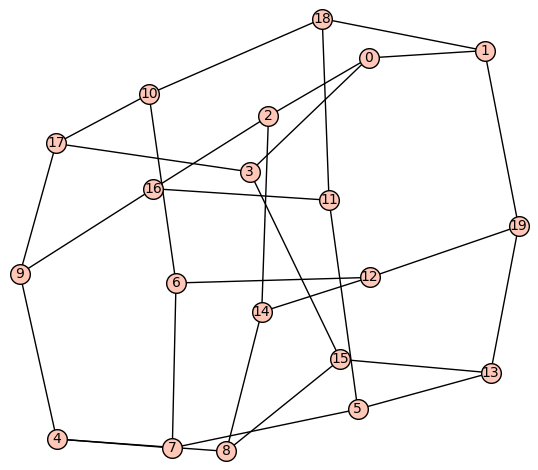

In [2]:
crossing6b = "Ss???[GA?C?_?_@?CCO`AGD?OWA?WA?E?"
G = Graph(crossing6b)
n, m = G.order(), G.size()
print(f"n = {n}, m = {m}")
G.plot()

## Part 1: Gröbner Basis Certification

First, we solve for $\lambda_2$ and a parametrization $B$ algebraically.

In [3]:
L = G.laplacian_matrix().change_ring(AA) # Work over the algebraic reals AA
lam2 = sorted(L.eigenvalues())[1]
E = (L - lam2 * matrix.identity(n)).kernel()
basis = E.basis()
d = len(basis)
print(f"lambda_2 = {lam2}, eigenspace dim = {d}")

lambda_2 = 1, eigenspace dim = 3


We can take a look at the basis:

In [4]:
basis

[(1.0000000000000?, 0.?e-13, 1.0000000000000?, 1.0000000000000?, 0.?e-13, -1.0000000000000?, -1.0000000000000?, -1.0000000000000?, 0.?e-12, 1.000000000000?, 0.?e-12, 0.?e-12, -1.000000000000?, -1.000000000000?, 0.?e-12, 0.?e-12, 1.000000000000?, 1.000000000000?, 0.?e-12, -1.000000000000?),
 (0.?e-13, 1.0000000000000?, -1/2, -1/2, -1, 1/2, 1/2, 0, 0.?e-12, -2.000000000000?, -0.500000000000?, -0.500000000000?, 1.500000000000?, 1.500000000000?, 0.500000000000?, 0.500000000000?, -1.500000000000?, -1.500000000000?, 0.?e-12, 2.000000000000?),
 (0.?e-13, 0.?e-13, 0, 0, 0, 0, 0, 0, 1.000000000000?, -1.000000000000?, -1.000000000000?, -1.000000000000?, 1.000000000000?, 1.000000000000?, 1.000000000000?, 1.000000000000?, -1.000000000000?, -1.000000000000?, -1.000000000000?, 1.000000000000?)]

Note that when working over $\bar{\mathbb{Q}}$, or the algebraic reals, Sage displays floating point approximations, but stores elements exactly as minimal polynomials. Even though the output in the previous cell looks like Sage is using numeric approximations, we can always display the exact values:

In [5]:
for phi in basis:
    print([entry.radical_expression() for entry in  phi])

[1, 0, 1, 1, 0, -1, -1, -1, 0, 1, 0, 0, -1, -1, 0, 0, 1, 1, 0, -1]
[0, 1, -1/2, -1/2, -1, 1/2, 1/2, 0, 0, -2, -1/2, -1/2, 3/2, 3/2, 1/2, 1/2, -3/2, -3/2, 0, 2]
[0, 0, 0, 0, 0, 0, 0, 0, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, 1]


### Edge orbits

Now we compute the automorphism group $\Psi = \operatorname{Aut}(G)$.

In [6]:
aut_group = G.automorphism_group()
edge_orbits = get_edge_orbits(G, aut_group.gens())
print(f"|Aut(G)| = {aut_group.order()}")
print(f"Edge orbits: {len(edge_orbits)}, sizes = {[len(o) for o in edge_orbits]}")

|Aut(G)| = 24
Edge orbits: 3, sizes = [12, 6, 12]


We see that $\|\operatorname{Aut}(g)\| = 24$ and partitions $G$ into 3 edge orbits.

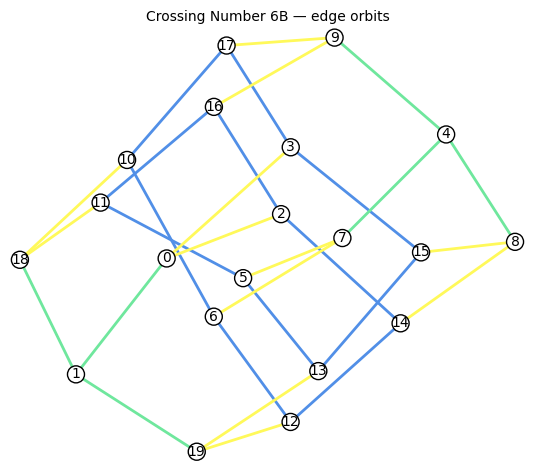

In [7]:
palette = ['#518FE7', '#6FE79D', '#FFF95A']
edge_colors = {palette[i]: [tuple(e) for e in orbit] for i, orbit in enumerate(edge_orbits)}
G.plot(edge_colors=edge_colors, vertex_size=150,
       vertex_colors={'white': G.vertices(sort=True)},
       edge_thickness=2, title='Crossing Number 6B — edge orbits')

### Solving the quadratic system

We now need to construct the **orbit-isometry ideal**. The set of 1-dimensional orbit-isometric embeddings is the ideal generated by the quadratic equations
$$
  \langle Bx,\, L_i\, Bx \rangle - |O_i|, \qquad 1 \leq i \leq 3.
$$
In our case, this is an ideal generated by 3 quadratic equations.

In [8]:
R = PolynomialRing(QQ, names=[f'x{i}' for i in range(d)], order='lex')
x = R.gens()

equations = []
for orbit in edge_orbits:
    energy = R(0)
    for u, v in orbit:
        phi_u = sum(x[j] * basis[j][u] for j in range(d))
        phi_v = sum(x[j] * basis[j][v] for j in range(d))
        energy += (phi_u - phi_v)**2
    equations.append(energy - len(orbit))

I = R.ideal(equations)
print(I)
print(f"dimension: {I.dimension()}")

Ideal (8*x0^2 - 16*x0*x1 - 8*x0*x2 + 12*x1^2 + 16*x1*x2 + 8*x2^2 - 12, 4*x0^2 - 8*x0*x1 - 4*x0*x2 + 6*x1^2 + 8*x1*x2 + 4*x2^2 - 6, 3*x1^2 - 12) of Multivariate Polynomial Ring in x0, x1, x2 over Rational Field
dimension: 1


We now solve for a Groebner basis.

In [9]:
gb = I.groebner_basis()
gb

[x0^2 - 2*x0*x1 - x0*x2 + 2*x1*x2 + x2^2 + 9/2, x1^2 - 4]

From the second generator $x_1^2 - 4 = 0$ we immediately read off $x_1 = \pm 2$. Substituting each value into the first generator yields two components of $V(I)$, each an ellipse in the $(x_0, x_2)$-plane. The two components arise from the fact that $-\varphi$ is a solution whenever $\varphi$ is.

In [10]:
for val in [2, -2]:
    print(f'x1 = {val:+d}:', gb[0].subs({x[1]: val}))

x1 = +2: x0^2 - x0*x2 - 4*x0 + x2^2 + 4*x2 + 9/2
x1 = -2: x0^2 - x0*x2 + 4*x0 + x2^2 - 4*x2 + 9/2


We can plot the variety in the $x_0x_2$-plane.

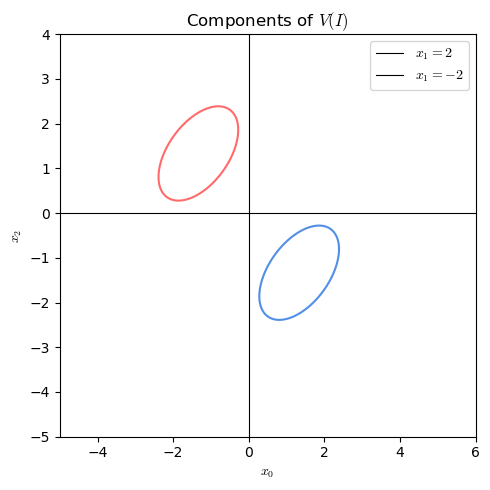

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def gb0(x0, x1, x2):
    return x0**2 - 2*x0*x1 - x0*x2 + 2*x1*x2 + x2**2 + 4.5

x0_arr = np.linspace(-5, 6, 600)
x2_arr = np.linspace(-5, 4, 600)
X0, X2 = np.meshgrid(x0_arr, x2_arr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.contour(X0, X2, gb0(X0, 2, X2),  levels=[0], colors=['#518FE7'])
ax.contour(X0, X2, gb0(X0, -2, X2), levels=[0], colors=['#FF6B6B'])
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_2$')
ax.set_title('Components of $V(I)$')
ax.legend(['$x_1 = 2$', '$x_1 = -2$'])
plt.tight_layout()
plt.show()

If we substitute $x_1 = 2$, $x_2=-2$, we recover the certificate from Example 5.10

In [12]:
B = matrix(AA, basis).transpose()

f = gb[0].subs({x[1]: 2, x[2]: -2})
x0_sols = f.univariate_polynomial().roots(AA, multiplicities=False)
x0 = x0_sols[0]

xvec = vector(AA, [x0, 2, -2])
phi = B * xvec
print(f'x   = ({x0.radical_expression()}, 2, -2)')
print(f'phi = {[v.radical_expression() for v in phi]}')

x   = (-1/2*sqrt(2) + 1, 2, -2)
phi = [-1/2*sqrt(2) + 1, 2, -1/2*sqrt(2), -1/2*sqrt(2), -2, 1/2*sqrt(2), 1/2*sqrt(2), 1/2*sqrt(2) - 1, -2, -1/2*sqrt(2) - 1, 1, 1, 1/2*sqrt(2), 1/2*sqrt(2), -1, -1, -1/2*sqrt(2), -1/2*sqrt(2), 2, 1/2*sqrt(2) + 1]


We can check that this is indeed a 1-dimensional orbit-isometric embedding.

In [13]:
L_AA = G.laplacian_matrix().change_ring(AA)
print('Eigenfunction check (L*phi == lam2*phi):', L_AA * phi == lam2 * phi)
print('Orbit energy checks:')
for orbit in edge_orbits:
    energy = sum((phi[u] - phi[v])**2 for u, v in orbit)
    print(f'  |O| = {len(orbit)}, energy = {energy}, ok = {energy == len(orbit)}')

Eigenfunction check (L*phi == lam2*phi): True
Orbit energy checks:
  |O| = 12, energy = 12, ok = True
  |O| = 6, energy = 6, ok = True
  |O| = 12, energy = 12, ok = True


We can visualize the corresponding edge-isometric symmetrized embedding correspond to $\varphi$. The plot on the left shows the PCA projection onto $\mathbb{R}^2$, and the plot on the right shows the full edge-isometric embedding in $\mathbb{R}^3$.

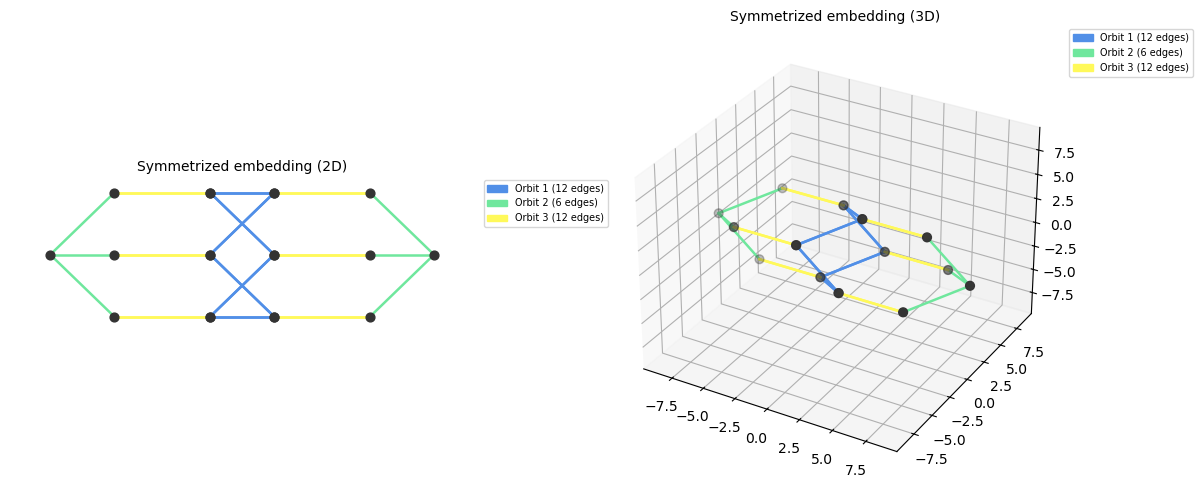

In [14]:
from cr.viz import plot_symmetrized_embedding

phi_np = np.array([float(v) for v in phi])
aut_perms = [[sigma(i) for i in range(n)] for sigma in aut_group]

fig = plt.figure(figsize=(12, 5))
ax2d = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection='3d')

plot_symmetrized_embedding(G, phi_np, aut_perms, edge_orbits=edge_orbits,
                           colors=palette, dim=2, ax=ax2d, title='Symmetrized embedding (2D)')
plot_symmetrized_embedding(G, phi_np, aut_perms, edge_orbits=edge_orbits,
                           colors=palette, dim=3, ax=ax3d, title='Symmetrized embedding (3D)')
plt.tight_layout()
plt.show()

Recall that the term "embedding" is a misnomer in the sense that the spectral embedding does not have to be injective. Here we have several vertices mapping to the same point.

## Part 2: Polyhedral Certification

Now we follow §7 to certify lower conformal rigidity using the structure of $\mathcal{E}_{\lambda_2}$ as a $\Psi$ representation. If $\mathcal{E}_{\lambda_2}$ decomposes into distinct real irreducibles under $\Psi = \operatorname{Aut}(G)$, we can apply Theorem 7.3: the set of achievable orbit-energy distributions is a polyhedral cone spanned by the orbit-energy vectors of one representative per isotypic component. $G$ is lower conformally rigid iff the target vector $(|O_1|, |O_2|, |O_3|) = (12, 6, 12)$ lies in this cone.

In [15]:
load('../cr/exact_cert.sage')

### Exact eigenspace and subrep

We reuse the `lam2` and `basis` already computed over `AA` and pass them directly to `build_subrep`.

In [16]:
B_exact = matrix(AA, basis)
print(f'λ₂ = {lam2},  dim E_λ₂ = {B_exact.nrows()}')
subrep = build_subrep(B_exact, aut_group)

λ₂ = 1,  dim E_λ₂ = 3


### Irreducible decomposition

We decompose $\mathcal{E}_{\lambda_2}$ as a $\Psi$-representation using the character table. The Frobenius–Schur indicator classifies each active complex irrep as real (FS = +1), complex (FS = 0), or quaternionic (FS = −1).

In [18]:
ct = aut_group.character_table()
classes = aut_group.conjugacy_classes()

chi = subrep_character(subrep, aut_group)
decomp = irrep_decomposition(chi, aut_group, ct, classes)
fs = frobenius_schur_indicators(aut_group, ct, classes, decomp)

print('idx  dim  mult  FS')
for idx, dim, mult in decomp:
    print(f'{idx:>3}  {dim:>3}  {mult:>4}  {fs[idx]:>2}')

idx  dim  mult  FS
  3    1     1   1
  4    2     1   1


We see that $\mathcal{E}_{\lambda_2} = X_1 \oplus X_2$ decomposes into one 1-dimensional real irreducible $X_1$ and one 2-dimensional irreducible $X_2$, so we can apply Theorem 7.3.

### Isotypic representatives and orbit energies

Since both active irreps have FS = +1 (real type), there are no complex conjugate pairs to combine. We get the orthogonal projectors onto each $X_j$ to sample a vector $\varphi_j$ from each and then compute their orbit energies $\ell_\Psi(\varphi_j)$.

In [19]:
projectors = isotypic_projectors(subrep, aut_group, ct, classes, decomp)
phi_vectors = get_isotypic_representative(projectors, B_exact)
energies = orbit_energies(phi_vectors, edge_orbits)

print('Orbit sizes:', [len(o) for o in edge_orbits])
for idx, ells in energies.items():
    print(f'  irrep {idx}: {[e.radical_expression() for e in ells]}')

Orbit sizes: [12, 6, 12]
  irrep 3: [4/3, 2/3, 3]
  irrep 4: [8, 4, 0]


### Polyhedral feasibility

We need to find nonnegative weights $a_1,a_2 \geq 0$ such that $a_1 \ell_\Psi(\varphi_1) + a_2 \ell_\Psi(\varphi_2) = (12,6,12)$. Doing so gives us the following solution $\varphi$

In [20]:
weights = exact_weights(energies, edge_orbits)
print('Weights:', {k: v.radical_expression() for k, v in weights.items()})
phi = combine_certificate(phi_vectors, weights)
print(f'phi = {[v.radical_expression() for v in phi]}')

Weights: {3: 4, 4: 5/6}
phi = [1/2*sqrt(10/3) + 4/3, 2, 1/2*sqrt(10/3) + 1/3, 1/2*sqrt(10/3) + 1/3, -2, -1/2*sqrt(10/3) - 1/3, -1/2*sqrt(10/3) - 1/3, -1/2*sqrt(10/3) - 4/3, -4/3, 1/2*sqrt(10/3) - 4/3, 1/3, 1/3, -1/2*sqrt(10/3) + 1/3, -1/2*sqrt(10/3) + 1/3, -1/3, -1/3, 1/2*sqrt(10/3) - 1/3, 1/2*sqrt(10/3) - 1/3, 4/3, -1/2*sqrt(10/3) + 4/3]


As before, we can verify that this satisfies the orbit-isometry conditions.

In [21]:
print('Eigenfunction check (L*phi == lam2*phi):', L_AA * phi == lam2 * phi)
print('Orbit energy checks:')
for orbit in edge_orbits:
    energy = sum((phi[u] - phi[v])**2 for u, v in orbit)
    print(f'  |O| = {len(orbit)}, energy = {energy}, ok = {energy == len(orbit)}')

Eigenfunction check (L*phi == lam2*phi): True
Orbit energy checks:
  |O| = 12, energy = 12, ok = True
  |O| = 6, energy = 6, ok = True
  |O| = 12, energy = 12, ok = True


And we can plot the symmetrized embedding:

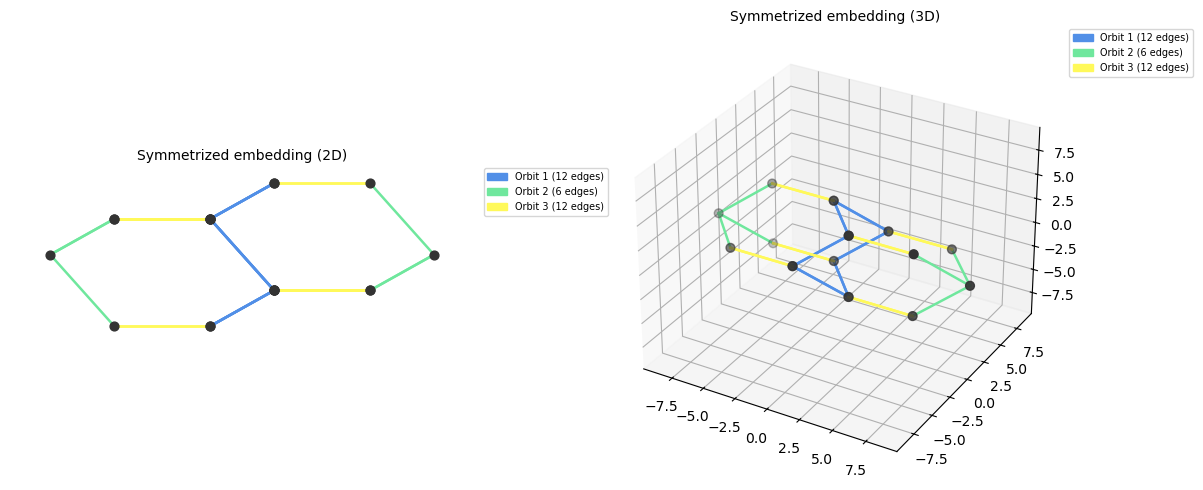

In [22]:
phi_np = np.array([float(v) for v in phi])
aut_perms = [[sigma(i) for i in range(n)] for sigma in aut_group]

fig = plt.figure(figsize=(12, 5))
ax2d = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection='3d')

plot_symmetrized_embedding(G, phi_np, aut_perms, edge_orbits=edge_orbits,
                           colors=palette, dim=2, ax=ax2d, title='Symmetrized embedding (2D)')
plot_symmetrized_embedding(G, phi_np, aut_perms, edge_orbits=edge_orbits,
                           colors=palette, dim=3, ax=ax3d, title='Symmetrized embedding (3D)')
plt.tight_layout()
plt.show()

which looks slightly different from the earlier embedding.